## REGIONES Y FRONTERAS

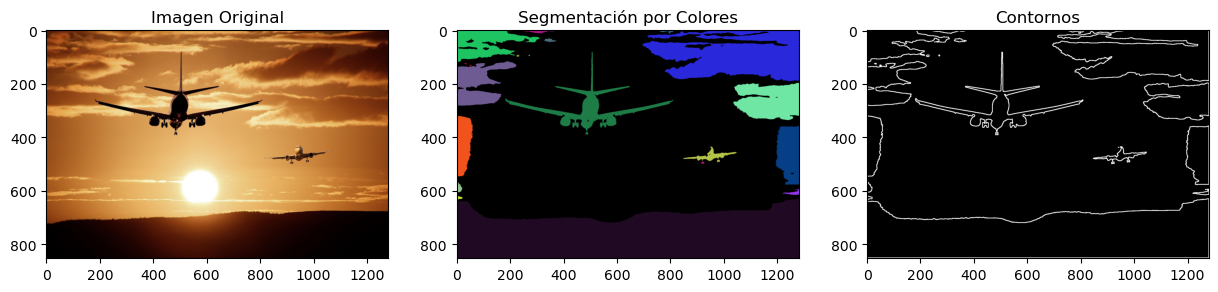

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

img = cv2.imread('imagen1.jpg') 
gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# combino tecnicas
blur=cv2.GaussianBlur(gray,(7,7),0)
_,binary=cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
# encontramos las regiones
num_l,label=cv2.connectedComponents(binary)
#identificamos por colores
color=np.random.randint(0,255,(num_l,3),dtype=np.uint8)
# fondo negro
color[0]=[0,0,0]
colorear=color[label]

# encontrar fronteras
contornos,_=cv2.findContours(binary,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
contorno_fin=cv2.drawContours(np.zeros_like(gray),contornos,-1,255,2)

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(132)
plt.title('Segmentación por Colores')
plt.imshow(colorear)

plt.subplot(133)
plt.title('Contornos')
plt.imshow(contorno_fin, cmap='gray')
plt.show()

## CONTEO

Número de objetos detectados: 73


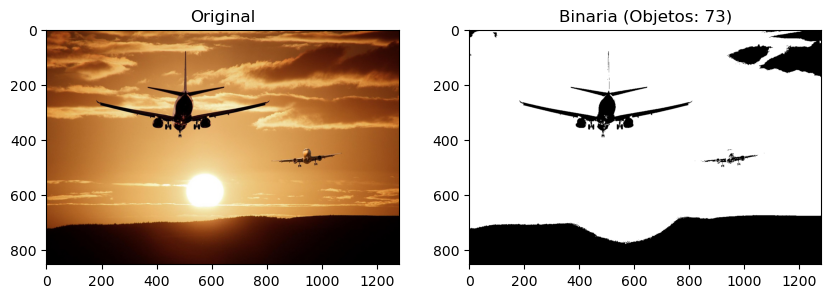

In [ ]:
import cv2
import numpy as np  
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(imagen):
    # 1. Grises
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # 2. Binarización
    _, binary = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    
    # 3. Etiquetado (connectivity=2 es 8-vecinos)
    e_img = measure.label(binary, connectivity=2)
    
    # 4. Conteo
    num_objetos = np.max(e_img)
    
    return num_objetos, binary


ruta = r'C:\pdi26\CLASE05052026\imagen1.jpg'  
img = cv2.imread(ruta)

if img is None:
    print("No se pudo cargar la imagen. Verifica la ruta.")
else:
    total, imagen_binaria = contar_elementos(img)
    print(f"Número de objetos detectados: {total}")


    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    
    plt.subplot(1, 2, 2)
    plt.title(f"Binaria (Objetos: {total})")
    plt.imshow(imagen_binaria, cmap='gray')
    plt.show()